In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/speech/Assignment1"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy scipy matplotlib transformers torchaudio soundfile

In [ ]:
import torchaudio

dataset = torchaudio.datasets.LIBRISPEECH(
    root="/content",
    url="test-clean",
    download=True
)

waveform, sr, _, _, _, _ = dataset[0]

import soundfile as sf
sf.write("/content/drive/My Drive/speech/Assignment1/sample.wav",
         waveform.squeeze().numpy(), sr)

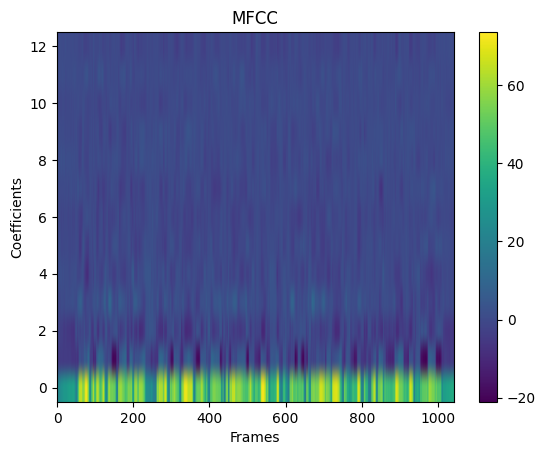

In [ ]:
#1. mfcc_manual.py
import numpy as np
import scipy.io.wavfile as wav
from scipy.fftpack import dct
import matplotlib.pyplot as plt

# -----------------------------
# Pre-emphasis
# -----------------------------
def pre_emphasis(signal, alpha=0.97):
    return np.append(signal[0], signal[1:] - alpha * signal[:-1])

# -----------------------------
# Framing
# -----------------------------
def framing(signal, sr, frame_size=0.025, frame_stride=0.01):
    frame_len = int(frame_size * sr)
    frame_step = int(frame_stride * sr)

    signal_len = len(signal)
    num_frames = int(np.ceil((signal_len - frame_len) / frame_step)) + 1

    pad_signal_len = num_frames * frame_step + frame_len
    pad_signal = np.append(signal, np.zeros(pad_signal_len - signal_len))

    indices = np.tile(np.arange(frame_len), (num_frames, 1)) + \
              np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_len, 1)).T

    frames = pad_signal[indices.astype(np.int32)]
    return frames

# -----------------------------
# Windowing
# -----------------------------
def apply_window(frames, window_type="hamming"):
    if window_type == "hamming":
        window = np.hamming(frames.shape[1])
    elif window_type == "hanning":
        window = np.hanning(frames.shape[1])
    else:
        window = np.ones(frames.shape[1])
    return frames * window

# -----------------------------
# FFT + Power Spectrum
# -----------------------------
def power_spectrum(frames, NFFT=512):
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))
    return (1.0 / NFFT) * (mag_frames ** 2)

# -----------------------------
# Mel Filterbank
# -----------------------------
def mel_filterbank(pow_frames, sr, nfilt=26, NFFT=512):
    def hz_to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    def mel_to_hz(mel): return 700 * (10**(mel / 2595) - 1)

    low_mel = hz_to_mel(0)
    high_mel = hz_to_mel(sr / 2)

    mel_points = np.linspace(low_mel, high_mel, nfilt + 2)
    hz_points = mel_to_hz(mel_points)

    bins = np.floor((NFFT + 1) * hz_points / sr)

    fbank = np.zeros((nfilt, int(NFFT / 2 + 1)))

    for m in range(1, nfilt + 1):
        f_m_minus = int(bins[m - 1])
        f_m = int(bins[m])
        f_m_plus = int(bins[m + 1])

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bins[m - 1]) / (bins[m] - bins[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bins[m + 1] - k) / (bins[m + 1] - bins[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    return np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)

# -----------------------------
# MFCC
# -----------------------------
def compute_mfcc(signal, sr):
    emphasized = pre_emphasis(signal)
    frames = framing(emphasized, sr)
    windowed = apply_window(frames, "hamming")
    pow_frames = power_spectrum(windowed)

    fbanks = mel_filterbank(pow_frames, sr)
    log_fbanks = np.log(fbanks)

    mfcc = dct(log_fbanks, type=2, axis=1, norm='ortho')[:, :13]
    return mfcc

# -----------------------------
# Run
# -----------------------------
if __name__ == "__main__":
    sr, signal = wav.read(f"{BASE_PATH}/sample.wav")

    if signal.ndim > 1:
        signal = signal[:, 0]

    mfcc = compute_mfcc(signal, sr)

    plt.imshow(mfcc.T, aspect='auto', origin='lower')
    plt.title("MFCC")
    plt.xlabel("Frames")
    plt.ylabel("Coefficients")
    plt.colorbar()
    plt.show()

/tmp/ipykernel_9753/1228020710.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10(np.sum(signal**2) / np.sum(noise**2))


rectangular -> Leakage: 0.9725, SNR: inf dB
hamming -> Leakage: 0.9722, SNR: 4.63 dB
hanning -> Leakage: 0.9732, SNR: 3.90 dB


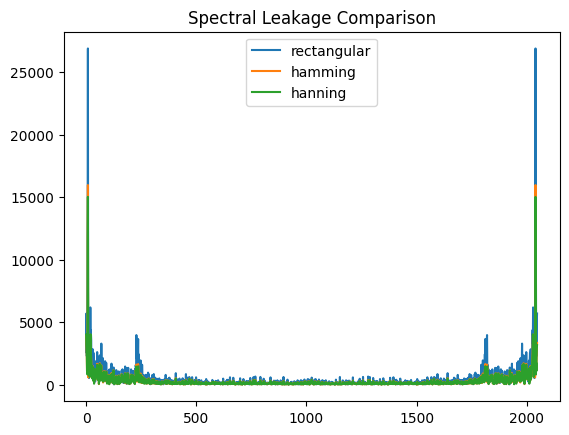

In [ ]:
#2 leakage_snr.py
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

def apply_window(signal, type):
    if type == "hamming":
        return signal * np.hamming(len(signal))
    elif type == "hanning":
        return signal * np.hanning(len(signal))
    else:
        return signal

def compute_fft(signal):
    return np.abs(np.fft.fft(signal))

def compute_snr(signal, noisy):
    noise = noisy - signal
    return 10 * np.log10(np.sum(signal**2) / np.sum(noise**2))

def leakage_measure(spectrum):
    main_peak = np.max(spectrum)
    leakage = np.sum(spectrum) - main_peak
    return leakage / np.sum(spectrum)

if __name__ == "__main__":
    sr, signal = wav.read(f"{BASE_PATH}/sample.wav")
    signal = signal[:2048]

    windows = ["rectangular", "hamming", "hanning"]

    for w in windows:
        win_signal = apply_window(signal, w)
        spectrum = compute_fft(win_signal)

        leakage = leakage_measure(spectrum)
        snr = compute_snr(signal, win_signal)

        print(f"{w} -> Leakage: {leakage:.4f}, SNR: {snr:.2f} dB")

        plt.plot(spectrum, label=w)

    plt.legend()
    plt.title("Spectral Leakage Comparison")
    plt.show()

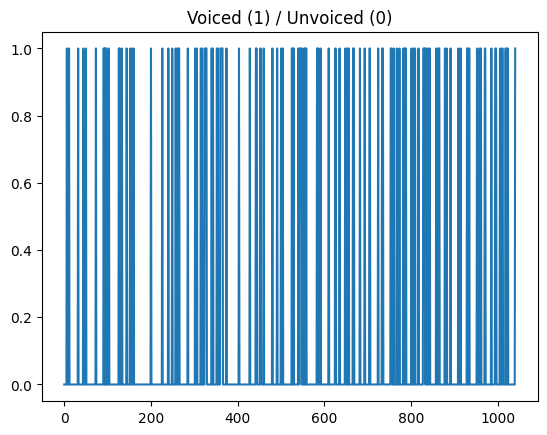

In [ ]:
#3. voiced_unvoiced.py
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

def cepstrum(frame):
    spectrum = np.fft.fft(frame)
    log_spec = np.log(np.abs(spectrum) + 1e-10)
    return np.fft.ifft(log_spec).real

def classify_frame(frame, threshold=0.1):
    c = cepstrum(frame)
    high_quef = c[20:100]  # pitch region

    if np.max(high_quef) > threshold:
        return 1  # voiced
    return 0  # unvoiced

def process(signal, sr):
    frame_len = int(0.025 * sr)
    step = int(0.01 * sr)

    labels = []

    for i in range(0, len(signal) - frame_len, step):
        frame = signal[i:i + frame_len]
        labels.append(classify_frame(frame))

    return labels
###############################################################################

def get_boundaries(labels, frame_step=0.01):
    boundaries = []
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            boundaries.append(i * frame_step)
    return boundaries

def get_model_boundaries(logits, sr, input_length):
    probs = torch.argmax(logits, dim=-1)[0].numpy()

    boundaries = []
    for i in range(1, len(probs)):
        if probs[i] != probs[i-1]:
            time = (i / len(probs)) * input_length
            boundaries.append(time)
    return boundaries

def compute_rmse(manual, model):
    min_len = min(len(manual), len(model))
    manual = np.array(manual[:min_len])
    model = np.array(model[:min_len])

    return np.sqrt(np.mean((manual - model) ** 2))


if __name__ == "__main__":
    sr, signal = wav.read(f"{BASE_PATH}/sample.wav")

    labels = process(signal, sr)

    plt.plot(labels)
    plt.title("Voiced (1) / Unvoiced (0)")
    plt.show()

In [ ]:
import numpy as np
import scipy.io.wavfile as wav

BASE_PATH = "/content/drive/MyDrive/speech/Assignment1"

def load_wav(path):
    sr, signal = wav.read(path)
    if signal.ndim > 1:
        signal = signal[:, 0]
    return signal.astype(np.float32), sr

Boundaries: [0.06, 0.5, 0.62, 0.7000000000000001, 0.78, 1.04, 1.1, 1.1500000000000001, 1.22, 1.32]


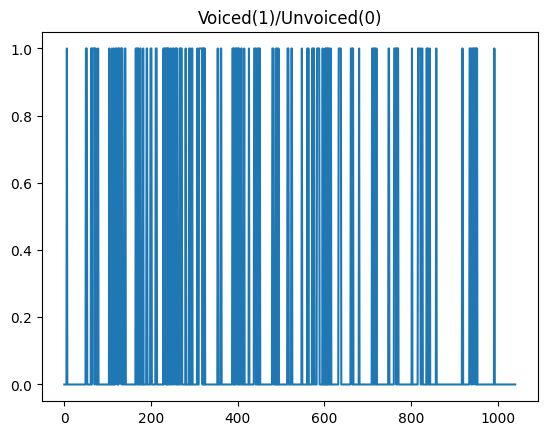

In [ ]:
#3 phonetic_mapping.py
import numpy as np
import matplotlib.pyplot as plt
#from common import load_wav, BASE_PATH

def cepstrum(frame):
    spec = np.fft.fft(frame)
    log_spec = np.log(np.abs(spec) + 1e-10)
    return np.fft.ifft(log_spec).real

def classify(frame):
    energy = np.sum(frame**2)
    zcr = np.mean(np.abs(np.diff(np.sign(frame))))
    c = cepstrum(frame)
    cep_peak = np.max(c[20:100])

    if energy > 0.01 and zcr < 0.1 and cep_peak > 0.05:
        return 1
    return 0

def process(signal, sr):
    frame_len = int(0.025 * sr)
    step = int(0.01 * sr)

    labels = []
    for i in range(0, len(signal)-frame_len, step):
        frame = signal[i:i+frame_len]
        labels.append(classify(frame))

    return labels

def get_boundaries(labels, step=0.01, min_gap=0.05):
    boundaries = []
    last_boundary = -min_gap

    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            t = i * step

            # ignore very close boundaries
            if t - last_boundary >= min_gap:
                boundaries.append(t)
                last_boundary = t

    return boundaries

if __name__ == "__main__":
    signal, sr = load_wav(f"{BASE_PATH}/sample.wav")

    labels = process(signal, sr)
    boundaries = get_boundaries(labels)

    print("Boundaries:", boundaries[:10])

    plt.plot(labels)
    plt.title("Voiced(1)/Unvoiced(0)")
    plt.show()

In [ ]:
#4 phonetic_mapping.py

import torch
import numpy as np
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

#from voiced_unvoiced import process, get_boundaries
#from common import BASE_PATH

# Load model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

def load_audio(path):
    waveform, sr = torchaudio.load(path)
    return waveform.squeeze().numpy(), sr

def get_logits_and_text(signal, sr):
    inputs = processor(signal, sampling_rate=sr, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred_ids = torch.argmax(logits, dim=-1)

    text = processor.decode(pred_ids[0])
    return text, logits

def get_model_boundaries(logits, duration):
    pred = torch.argmax(logits, dim=-1)[0].cpu().numpy()

    boundaries = []
    for i in range(1, len(pred)):
        if pred[i] != pred[i-1]:
            t = (i / len(pred)) * duration
            boundaries.append(t)

    return boundaries

def smooth_labels(labels, window=5):
    smoothed = []
    for i in range(len(labels)):
        start = max(0, i - window)
        end = min(len(labels), i + window)
        smoothed.append(round(np.mean(labels[start:end])))
    return smoothed

def compute_rmse(manual, model, duration):
    n = min(len(manual), len(model))
    manual = np.array(manual[:n])
    model = np.array(model[:n])

    rmse = np.sqrt(np.mean((manual - model) ** 2))

    return rmse, rmse / duration

if __name__ == "__main__":
    path = f"{BASE_PATH}/sample.wav"

    signal, sr = load_audio(path)
    duration = len(signal) / sr

    # Model output
    text, logits = get_logits_and_text(signal, sr)
    #model_boundaries = get_model_boundaries(logits, duration)

    # Manual segmentation
    labels = process(signal, sr)
    labels = smooth_labels(labels)
    #manual_boundaries = get_boundaries(labels)



    print("Transcription:", text)
    print("Manual boundaries:", manual_boundaries[:10])
    print("Model boundaries:", model_boundaries[:10])

    #rmse = compute_rmse(manual_boundaries, model_boundaries, duration)
    #print("RMSE:", rmse)

    rmse, norm_rmse = compute_rmse(manual_boundaries, model_boundaries, duration)

    print("RMSE:", rmse)
    print("Normalized RMSE:", norm_rmse)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transcription: HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOWER FAT AND SAUCE
Manual boundaries: [0.64, 0.73, 1.22, 1.72, 3.11, 3.2, 6.34, 6.390000000000001, 7.63, 9.46]
Model boundaries: [0.5608061420345489, 0.5808349328214971, 0.6008637236084453, 0.6409213051823417, 0.7010076775431863, 0.7210364683301345, 0.7410652591170825, 0.7811228406909789, 0.801151631477927, 0.8412092130518235]
RMSE: 4.441273066746715
Normalized RMSE: 0.42561313528957495
